In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Task 1: Exploring and Visualizing a Simple Dataset

## Introduction & Problem Statement

**Objective:** Understand how to read, summarize, and visualize a dataset using Python libraries.

**Dataset:** Iris Dataset - A classic dataset in machine learning containing measurements of iris flowers from three different species.

**Skills Covered:**
- Data loading and inspection using pandas
- Basic data summarization
- Visualization using matplotlib and seaborn


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


## Dataset Understanding & Description

The Iris dataset contains 150 samples from three species of iris flowers:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

**Features:**
- Sepal Length (cm)
- Sepal Width (cm)
- Petal Length (cm)
- Petal Width (cm)

**Target:** Species of the iris flower

In [3]:
# Load the Iris dataset from sklearn
iris = load_iris()

# Convert to pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print('Dataset loaded successfully!')
print(f"Shape of dataset: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape of dataset: (150, 5)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Display dataset structure
print("=== DATASET STRUCTURE ===")
print(f"Shape: {df.shape} (rows, columns)")
print(f"\nColumns:\n{df.columns.tolist()}")
print("\n=== DATA TYPES ===")
print(df.dtypes)
print("\n=== BASIC STATISTICS ===")
print(df.describe())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

=== DATASET STRUCTURE ===
Shape: (150, 5) (rows, columns)

Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

=== DATA TYPES ===
sepal length (cm)     float64
sepal width (cm)      float64
petal length (cm)     float64
petal width (cm)      float64
species              category
dtype: object

=== BASIC STATISTICS ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150

In [5]:
# Summary by species
print("=== SPECIES DISTRIBUTION ===")
print(df['species'].value_counts())

print("\n=== MEAN VALUES BY SPECIES ===")
print(df.groupby('species').mean())

=== SPECIES DISTRIBUTION ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

=== MEAN VALUES BY SPECIES ===
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                  5.006             3.428              1.462   
versicolor              5.936             2.770              4.260   
virginica               6.588             2.974              5.552   

            petal width (cm)  
species                       
setosa                 0.246  
versicolor             1.326  
virginica              2.026  


/tmp/ipykernel_16/1308351019.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('species').mean())


## Exploratory Data Analysis (EDA)

### 1. Scatter Plot - Relationship Between Variables

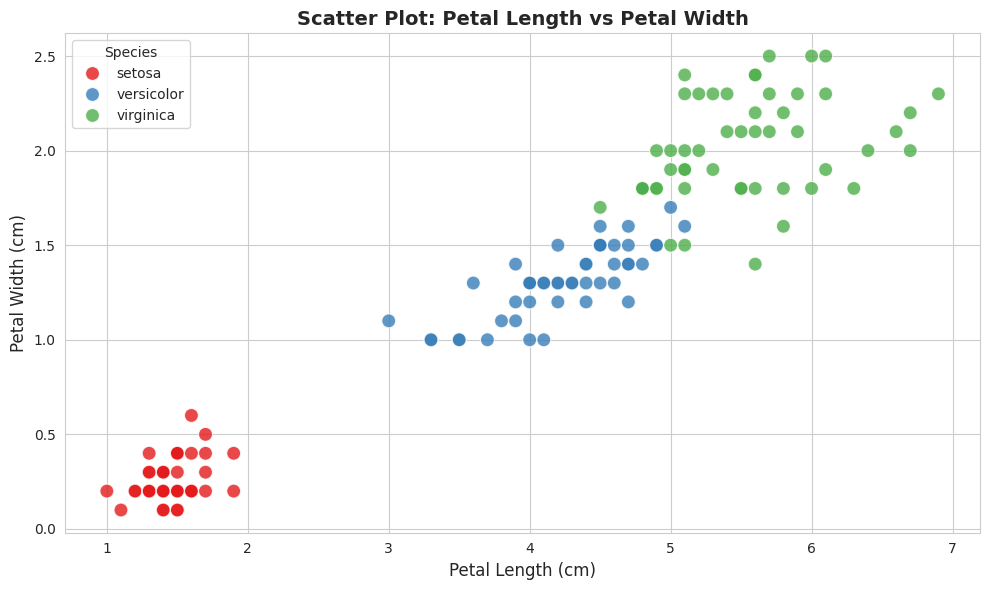

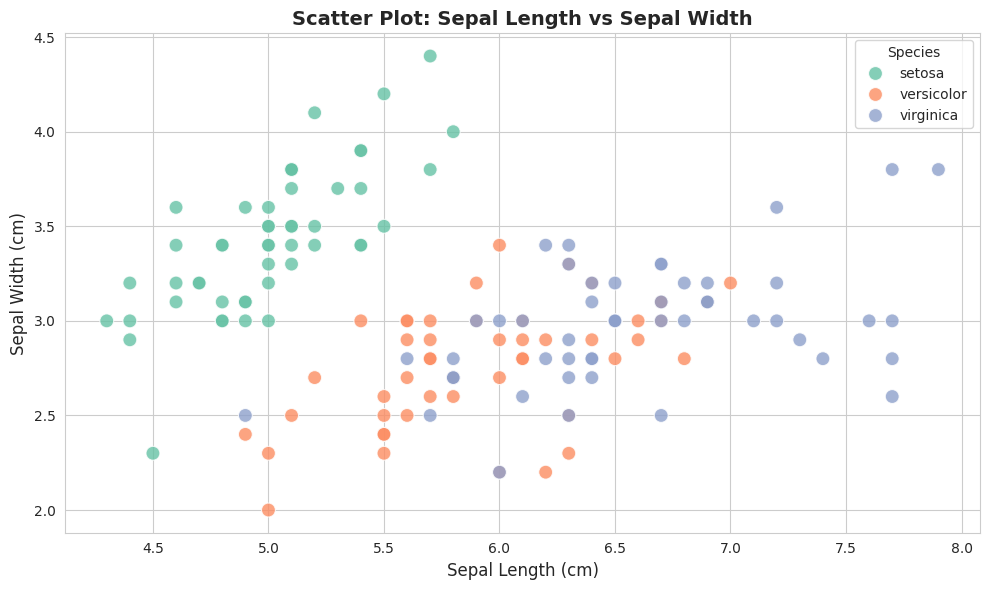

In [6]:
# Scatter plot: Petal Length vs Petal Width colored by species
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', 
                hue='species', palette='Set1', s=100, alpha=0.8)
plt.title('Scatter Plot: Petal Length vs Petal Width', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Species', loc='upper left')
plt.tight_layout()
plt.show()

# Another scatter plot: Sepal Length vs Sepal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', 
                hue='species', palette='Set2', s=100, alpha=0.8)
plt.title('Scatter Plot: Sepal Length vs Sepal Width', fontsize=14, fontweight='bold')
plt.xlabel('Sepal Length (cm)', fontsize=12)
plt.ylabel('Sepal Width (cm)', fontsize=12)
plt.legend(title='Species', loc='upper right')
plt.tight_layout()
plt.show()

### 2. Histogram - Data Distribution

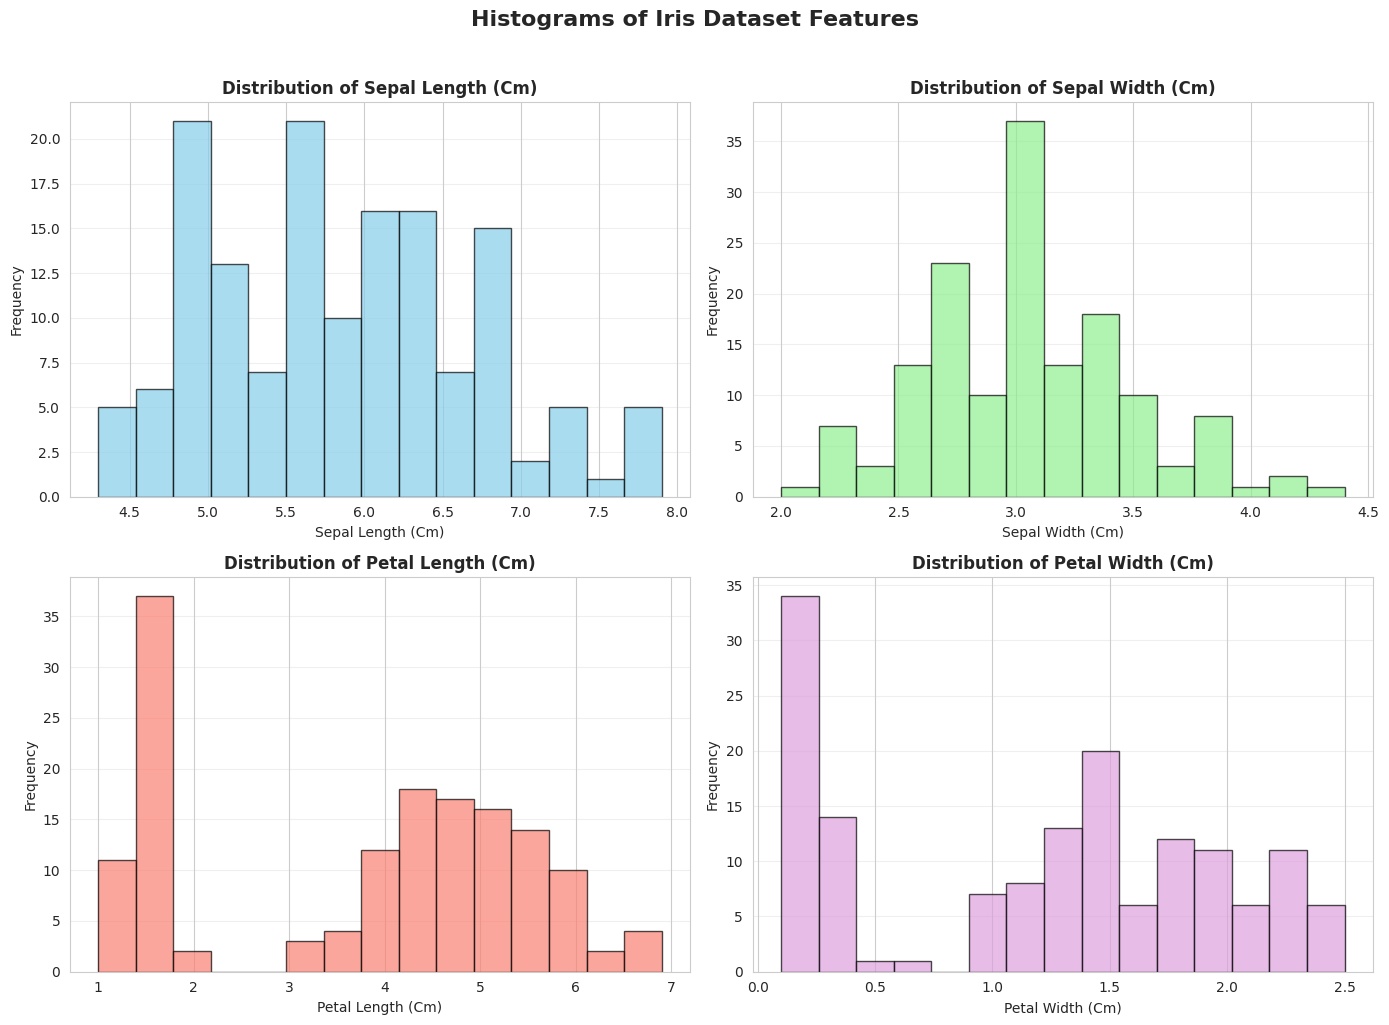

In [7]:
# Histograms for all numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature], bins=15, color=colors[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature.title()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature.title(), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Histograms of Iris Dataset Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3. Box Plot - Outliers and Spread

/tmp/ipykernel_16/302244644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[idx], palette='Pastel1')
/tmp/ipykernel_16/302244644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[idx], palette='Pastel1')
/tmp/ipykernel_16/302244644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=feature, ax=axes[idx], palette='Pastel1')
/tmp/ipykernel_16/302244644.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

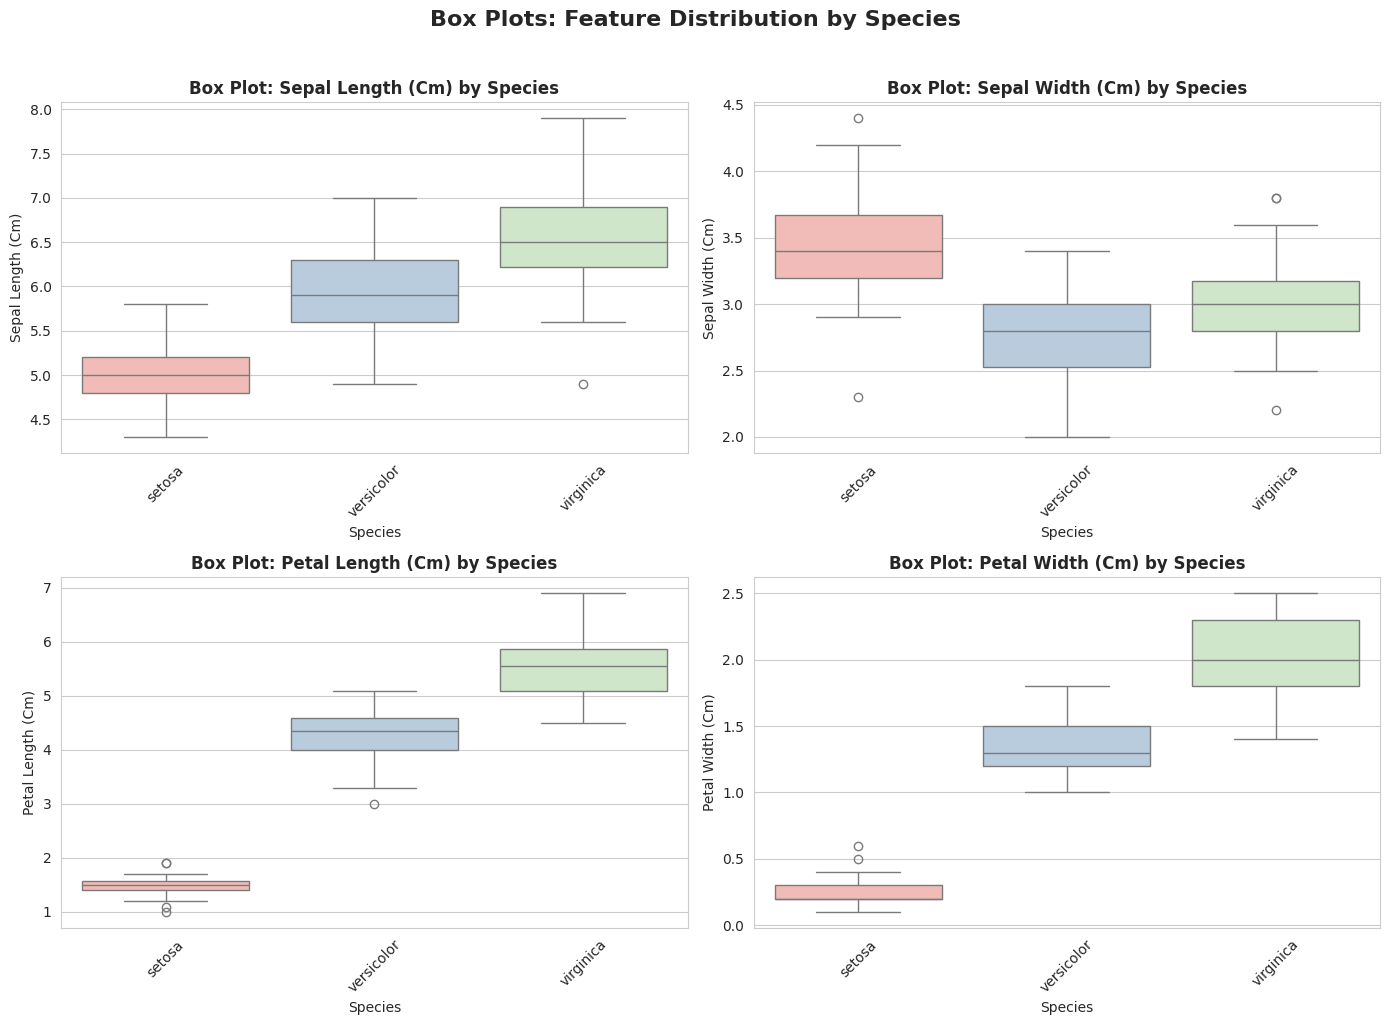

In [8]:
# Box plots for each feature by species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(features):
    sns.boxplot(data=df, x='species', y=feature, ax=axes[idx], palette='Pastel1')
    axes[idx].set_title(f'Box Plot: {feature.title()} by Species', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Species', fontsize=10)
    axes[idx].set_ylabel(feature.title(), fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Box Plots: Feature Distribution by Species', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

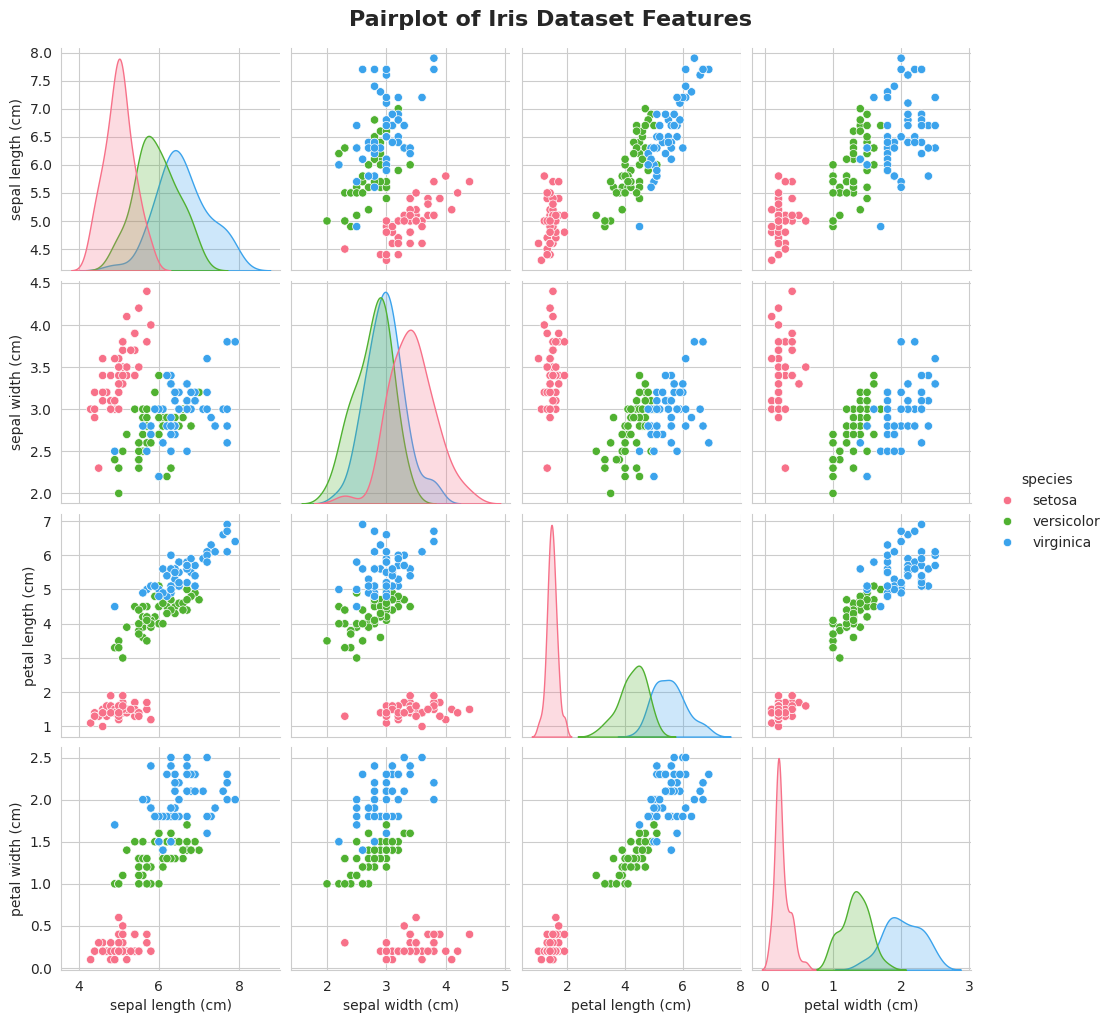

In [9]:
# Pairplot for comprehensive view
sns.pairplot(df, hue='species', palette='husl', diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Iris Dataset Features', fontsize=16, fontweight='bold', y=1.02)
plt.show()

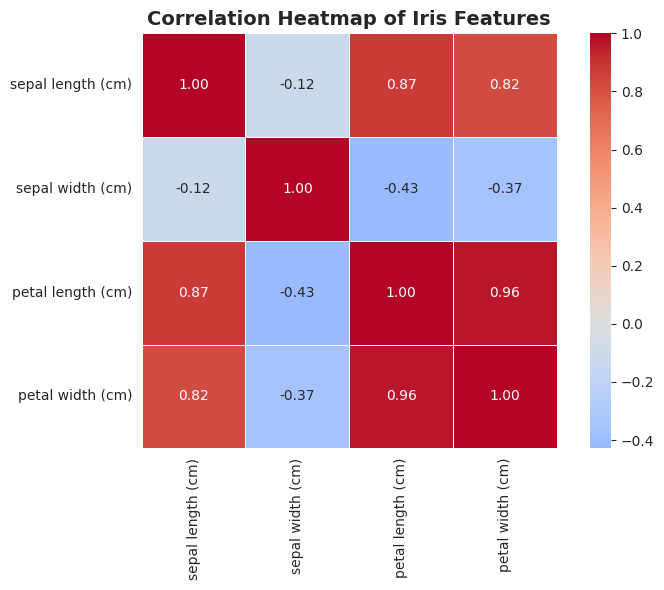

In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Iris Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

### Key Insights:

1. **Dataset Structure:** The Iris dataset contains 150 samples with 4 features and 1 target variable (species). No missing values were found.

2. **Species Distribution:** Each species (setosa, versicolor, virginica) has exactly 50 samples, making it a balanced dataset.

3. **Feature Relationships:**
   - **Petal Length vs Petal Width:** Strong positive correlation. Setosa is clearly separable from the other two species.
   - **Sepal Length vs Sepal Width:** Moderate correlation with some overlap between species.

4. **Outliers:** Very few outliers detected in box plots. Setosa species shows distinctively smaller petal measurements.

5. **Correlation:** Petal length and petal width are highly correlated (≈0.96), suggesting they carry similar information for classification.

### Skills Demonstrated:
- ✅ Data loading with pandas
- ✅ Dataset inspection (.shape, .columns, .head())
- ✅ Scatter plots for relationship analysis
- ✅ Histograms for distribution analysis
- ✅ Box plots for outlier detection
- ✅ Correlation analysis with heatmap